# 05 RFM Analysis and Retention Risk

## Purpose

This notebook analyses the customer-level RFM features generated during the
Feature Engineering stage.

The analysis aims to:

1. Examine the distribution of customer RFM characteristics.
2. Profile customers across RFM segments.
3. Analyse the relationship between RFM behaviour and retention risk.
4. Examine the 60-day inactivity rule.
5. Compare customer characteristics between active and at-risk customers.
6. Identify patterns that can inform retention strategy and subsequent
   predictive modelling.

The analysis uses the engineered customer-level dataset produced in
04_Feature_Engineering.ipynb.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [33]:
rfm = pd.read_csv(
    "../data/processed/rfm_customer_features.csv"
)

print("Dataset shape:", rfm.shape)

Dataset shape: (5878, 12)


In [34]:
rfm.head()

,Customer ID,LastPurchase,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,AtRisk60,RiskLevel
0,12346,2011-01-18 10:01:00,325.12,12,"77,556.46",2,5,5,12,Loyal Customers,True,At Risk
1,12347,2011-12-07 15:52:00,1.87,8,"4,921.53",5,4,5,14,Champions,False,Active
2,12348,2011-09-25 13:13:00,74.98,5,"2,019.40",3,4,4,11,Loyal Customers,True,At Risk
3,12349,2011-11-21 09:51:00,18.12,4,"4,428.69",5,3,5,13,Champions,False,Active
4,12350,2011-02-02 16:01:00,309.87,1,334.40,2,1,2,5,At Risk,True,At Risk


In [35]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Customer ID   5878 non-null   int64  
 1   LastPurchase  5878 non-null   object 
 2   Recency       5878 non-null   float64
 3   Frequency     5878 non-null   int64  
 4   Monetary      5878 non-null   float64
 5   R_Score       5878 non-null   int64  
 6   F_Score       5878 non-null   int64  
 7   M_Score       5878 non-null   int64  
 8   RFM_Score     5878 non-null   int64  
 9   RFM_Segment   5878 non-null   object 
 10  AtRisk60      5878 non-null   bool   
 11  RiskLevel     5878 non-null   object 
dtypes: bool(1), float64(2), int64(6), object(3)
memory usage: 511.0+ KB


In [36]:
print("Customers:", rfm["Customer ID"].nunique())
print(
    "Duplicate customers:",
    rfm["Customer ID"].duplicated().sum()
)

print(
    "Missing values:"
)
print(rfm.isna().sum())

Customers: 5878
Duplicate customers: 0
Missing values:
Customer ID     0
LastPurchase    0
Recency         0
Frequency       0
Monetary        0
R_Score         0
F_Score         0
M_Score         0
RFM_Score       0
RFM_Segment     0
AtRisk60        0
RiskLevel       0
dtype: int64


In [37]:
rfm[
    ["Recency", "Frequency", "Monetary", "RFM_Score"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,"5,878.00",200.85,209.35,0.00,25.05,95.04,379.10,738.12
Frequency,"5,878.00",6.29,13.01,1.00,1.00,3.00,7.00,398.00
Monetary,"5,878.00","2,955.90","14,440.85",2.95,342.28,867.74,"2,248.30","580,987.04"
RFM_Score,"5,878.00",9.00,3.64,3.00,6.00,9.00,12.00,15.00


In [38]:
segment_counts = (
    rfm["RFM_Segment"]
    .value_counts()
    .rename_axis("RFM_Segment")
    .reset_index(name="Customers")
)

segment_counts["Percentage"] = (
    segment_counts["Customers"]
    / len(rfm)
    * 100
)

segment_counts

,RFM_Segment,Customers,Percentage
0,Potential Loyalists,1451,24.69
1,Loyal Customers,1362,23.17
2,Champions,1290,21.95
3,At Risk,968,16.47
4,Lost / Low Value,807,13.73


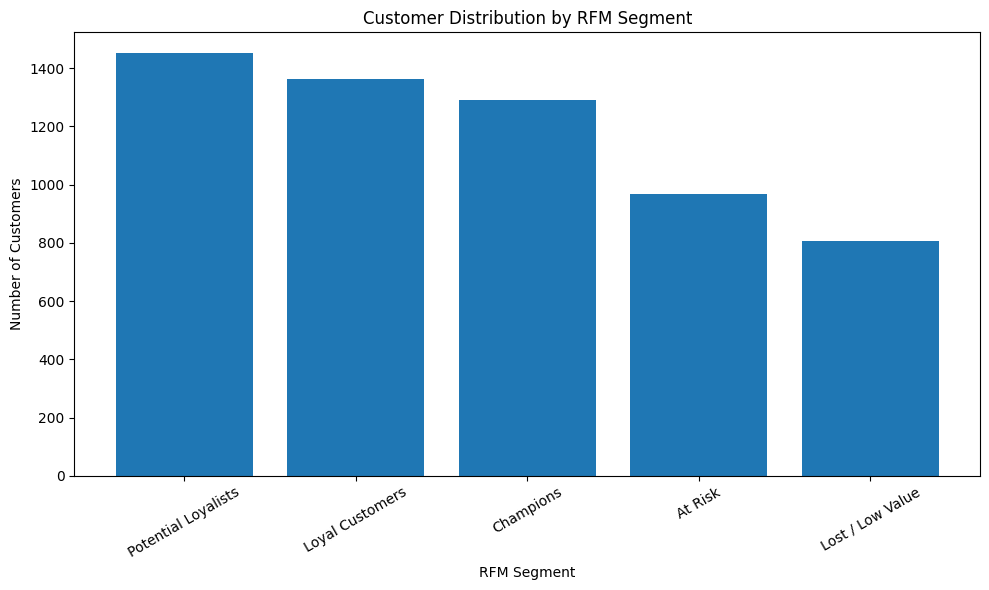

In [39]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_counts["RFM_Segment"],
    segment_counts["Customers"]
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [40]:
segment_profile = (
    rfm
    .groupby("RFM_Segment")
    .agg(
        Customers=("Customer ID", "nunique"),
        AvgRecency=("Recency", "mean"),
        MedianRecency=("Recency", "median"),
        AvgFrequency=("Frequency", "mean"),
        MedianFrequency=("Frequency", "median"),
        AvgMonetary=("Monetary", "mean"),
        MedianMonetary=("Monetary", "median"),
        AvgRFMScore=("RFM_Score", "mean")
    )
    .reset_index()
)

segment_profile

,RFM_Segment,Customers,AvgRecency,MedianRecency,AvgFrequency,MedianFrequency,AvgMonetary,MedianMonetary,AvgRFMScore
0,At Risk,968,320.07,358.37,1.41,1.00,386.36,333.46,5.48
1,Champions,1290,25.24,15.49,18.01,12.00,"9,705.45","4,534.33",14.02
2,Lost / Low Value,807,516.36,521.90,1.06,1.00,196.54,175.00,3.61
3,Loyal Customers,1362,95.06,53.07,5.57,5.00,"2,264.43","1,433.37",10.98
4,Potential Loyalists,1451,201.28,156.15,2.71,2.00,853.21,665.78,8.02


GHHG

In [61]:
# Recency distribution around the existing 60-day threshold

recency_thresholds = [30, 60, 90, 120, 180, 270, 365]

for threshold in recency_thresholds:
    count = (rfm["Recency"] > threshold).sum()
    percentage = count / len(rfm) * 100
    
    print(
        f"Recency > {threshold:>3} days: "
        f"{count:>5} customers "
        f"({percentage:.2f}%)"
    )

Recency >  30 days:  4230 customers (71.96%)
Recency >  60 days:  3481 customers (59.22%)
Recency >  90 days:  2989 customers (50.85%)
Recency > 120 days:  2757 customers (46.90%)
Recency > 180 days:  2400 customers (40.83%)
Recency > 270 days:  1926 customers (32.77%)
Recency > 365 days:  1609 customers (27.37%)


In [62]:
# RFM segments against the 60-day recency threshold

pd.crosstab(
    rfm["RFM_Segment"],
    rfm["Recency"] > 60,
    margins=True
)

Recency,False,True,All
RFM_Segment,,,
At Risk,74,894,968
Champions,1165,125,1290
Lost / Low Value,0,807,807
Loyal Customers,732,630,1362
Potential Loyalists,426,1025,1451
All,2397,3481,5878


In [64]:
# Compare RFM segment labels with the 60-day rule

risk_comparison = pd.crosstab(
    rfm["RFM_Segment"],
    rfm["Recency"] > 60,
    normalize="index"
) * 100

risk_comparison.round(2)

Recency,False,True
RFM_Segment,,
At Risk,7.64,92.36
Champions,90.31,9.69
Lost / Low Value,0.00,100.00
Loyal Customers,53.74,46.26
Potential Loyalists,29.36,70.64


In [65]:
# ============================================================
# 8. RULE-BASED RETENTION RISK
# ============================================================

RISK_THRESHOLD = 60

rfm["Retention_Risk"] = np.where(
    rfm["Recency"] > RISK_THRESHOLD,
    "At Risk",
    "Active"
)

rfm["Retention_Risk_Flag"] = (
    rfm["Recency"] > RISK_THRESHOLD
).astype(int)

In [66]:
risk_counts = (
    rfm["Retention_Risk"]
    .value_counts()
    .rename_axis("Retention_Risk")
    .reset_index(name="Customers")
)

risk_counts["Percentage"] = (
    risk_counts["Customers"] / len(rfm) * 100
).round(2)

risk_counts

,Retention_Risk,Customers,Percentage
0,At Risk,3481,59.22
1,Active,2397,40.78


In [ ]:
rfm[[
    "Customer ID",
    "Recency",
    "Frequency",
    "Monetary",
    "RFM_Score",
    "RFM_Segment",
    "Retention_Risk",
    "Retention_Risk_Flag"
]].head(10)

KeyError: "['RFM_Label'] not in index"

HHG

In [41]:
risk_summary = (
    rfm["RiskLevel"]
    .value_counts()
    .rename_axis("RiskLevel")
    .reset_index(name="Customers")
)

risk_summary["Percentage"] = (
    risk_summary["Customers"]
    / len(rfm)
    * 100
)

risk_summary

,RiskLevel,Customers,Percentage
0,At Risk,3482,59.24
1,Active,2396,40.76


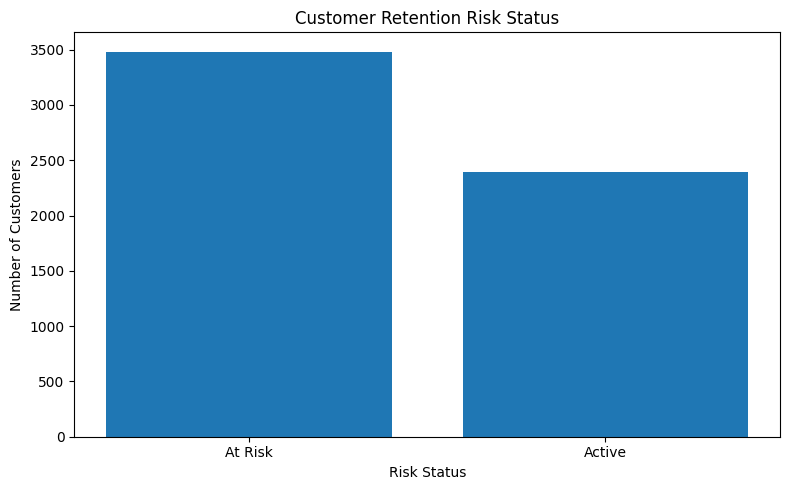

In [42]:
plt.figure(figsize=(8, 5))

plt.bar(
    risk_summary["RiskLevel"],
    risk_summary["Customers"]
)

plt.title("Customer Retention Risk Status")
plt.xlabel("Risk Status")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [43]:
risk_profile = (
    rfm
    .groupby("RiskLevel")
    .agg(
        Customers=("Customer ID", "nunique"),
        AvgRecency=("Recency", "mean"),
        MedianRecency=("Recency", "median"),
        AvgFrequency=("Frequency", "mean"),
        MedianFrequency=("Frequency", "median"),
        AvgMonetary=("Monetary", "mean"),
        MedianMonetary=("Monetary", "median"),
        AvgRFMScore=("RFM_Score", "mean")
    )
    .reset_index()
)

risk_profile

,RiskLevel,Customers,AvgRecency,MedianRecency,AvgFrequency,MedianFrequency,AvgMonetary,MedianMonetary,AvgRFMScore
0,Active,2396,22.67,19.03,10.61,6.00,"5,416.67","1,778.95",11.90
1,At Risk,3482,323.47,315.06,3.32,2.00,"1,262.62",542.97,7.00


In [44]:
risk_value = (
    rfm
    .groupby("RiskLevel")
    .agg(
        Customers=("Customer ID", "nunique"),
        TotalMonetary=("Monetary", "sum"),
        AverageMonetary=("Monetary", "mean"),
        MedianMonetary=("Monetary", "median")
    )
    .reset_index()
)

risk_value["RevenueShare"] = (
    risk_value["TotalMonetary"]
    / rfm["Monetary"].sum()
    * 100
)

risk_value

,RiskLevel,Customers,TotalMonetary,AverageMonetary,MedianMonetary,RevenueShare
0,Active,2396,"12,978,350.93","5,416.67","1,778.95",74.70
1,At Risk,3482,"4,396,453.34","1,262.62",542.97,25.30


In [45]:
risk_segment = pd.crosstab(
    rfm["RFM_Segment"],
    rfm["RiskLevel"]
)

risk_segment

RiskLevel,Active,At Risk
RFM_Segment,,
At Risk,74,894
Champions,1164,126
Lost / Low Value,0,807
Loyal Customers,732,630
Potential Loyalists,426,1025


In [46]:
risk_segment_pct = pd.crosstab(
    rfm["RFM_Segment"],
    rfm["RiskLevel"],
    normalize="index"
) * 100

risk_segment_pct

RiskLevel,Active,At Risk
RFM_Segment,,
At Risk,7.64,92.36
Champions,90.23,9.77
Lost / Low Value,0.00,100.00
Loyal Customers,53.74,46.26
Potential Loyalists,29.36,70.64


In [47]:
monetary_threshold = rfm["Monetary"].quantile(0.75)

print(
    "75th percentile monetary value:",
    round(monetary_threshold, 2)
)

75th percentile monetary value: 2248.3


In [48]:
rfm["HighValue"] = (
    rfm["Monetary"] >= monetary_threshold
)

In [49]:
high_value_at_risk = rfm[
    (rfm["HighValue"] == True) &
    (rfm["AtRisk60"] == True)
]

print(
    "High-value at-risk customers:",
    len(high_value_at_risk)
)

High-value at-risk customers: 426


In [50]:
high_value_at_risk_value = high_value_at_risk["Monetary"].sum()

print(
    "Historical monetary value of high-value at-risk customers:",
    round(high_value_at_risk_value, 2)
)

Historical monetary value of high-value at-risk customers: 2448115.6


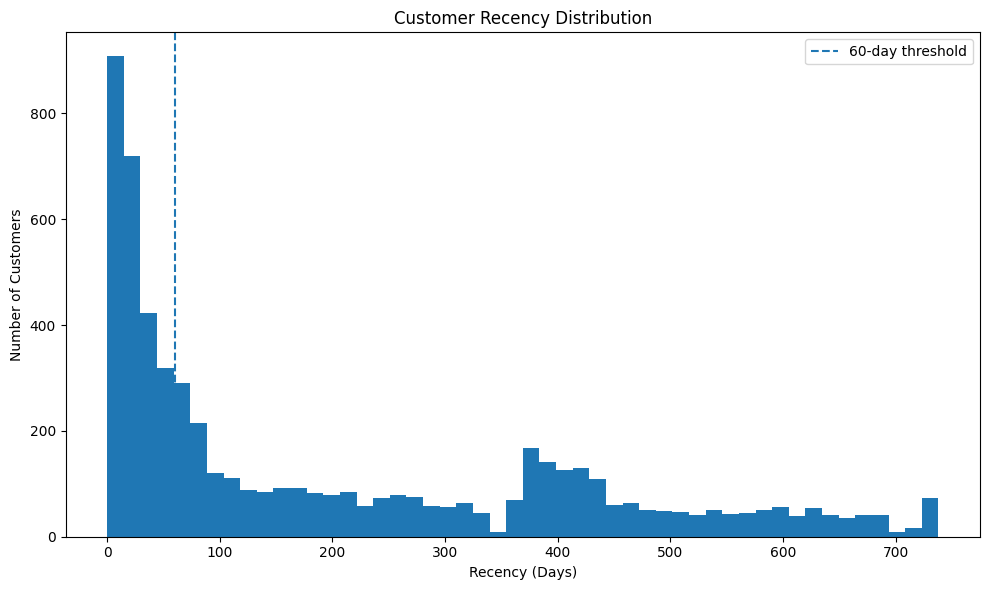

In [51]:
plt.figure(figsize=(10, 6))

plt.hist(
    rfm["Recency"],
    bins=50
)

plt.axvline(
    60,
    linestyle="--",
    label="60-day threshold"
)

plt.title("Customer Recency Distribution")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.legend()
plt.tight_layout()
plt.show()

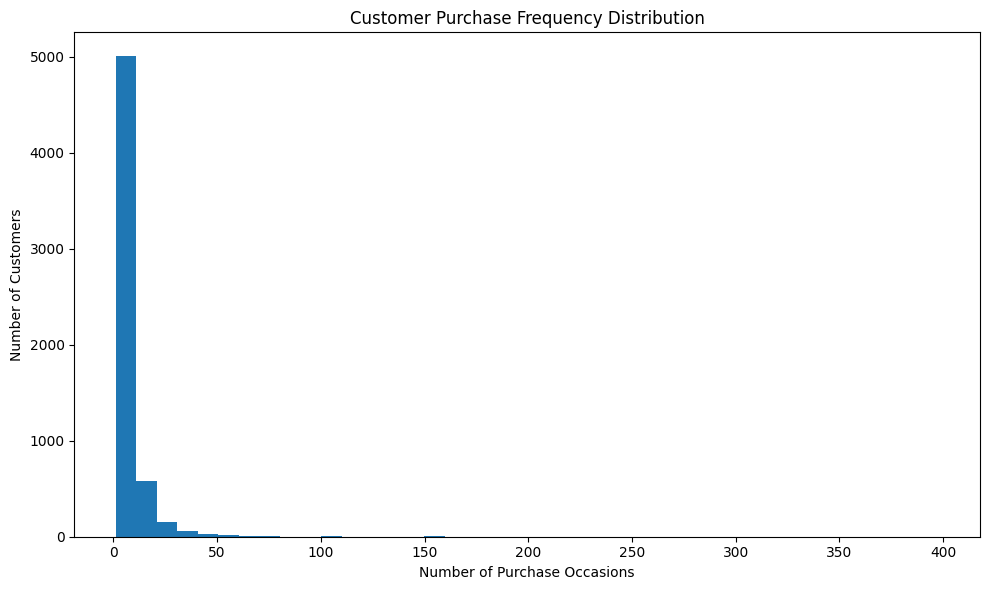

In [52]:
plt.figure(figsize=(10, 6))

plt.hist(
    rfm["Frequency"],
    bins=40
)

plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Purchase Occasions")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

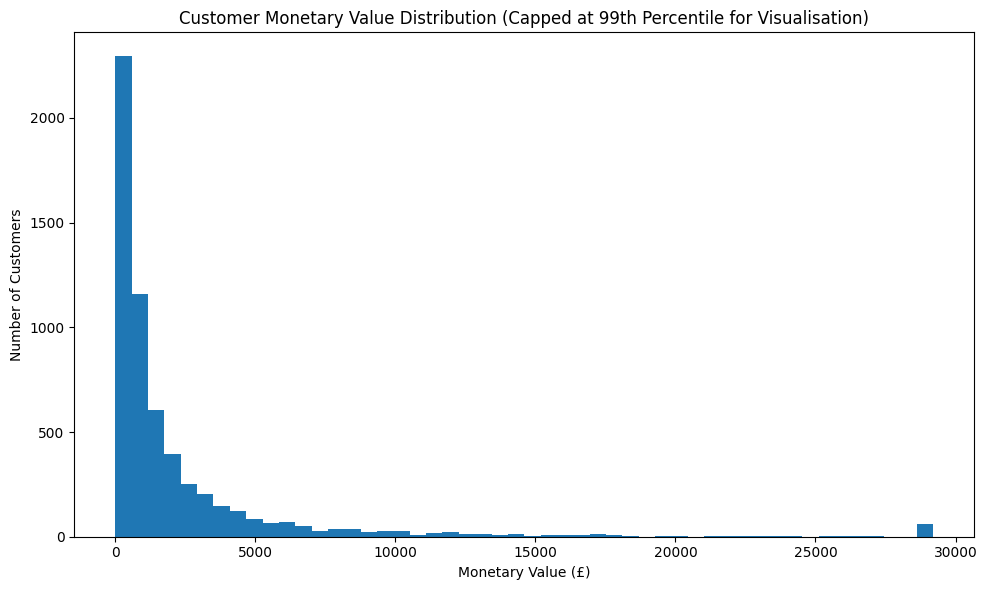

In [53]:
monetary_plot = rfm[
    "Monetary"
].clip(
    upper=rfm["Monetary"].quantile(0.99)
)

plt.figure(figsize=(10, 6))

plt.hist(
    monetary_plot,
    bins=50
)

plt.title(
    "Customer Monetary Value Distribution "
    "(Capped at 99th Percentile for Visualisation)"
)

plt.xlabel("Monetary Value (£)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [54]:
rfm_score_counts = (
    rfm["RFM_Score"]
    .value_counts()
    .sort_index()
)

rfm_score_counts

RFM_Score
3     318
4     489
5     503
6     465
7     473
8     471
9     507
10    457
11    475
12    430
13    437
14    386
15    467
Name: count, dtype: int64

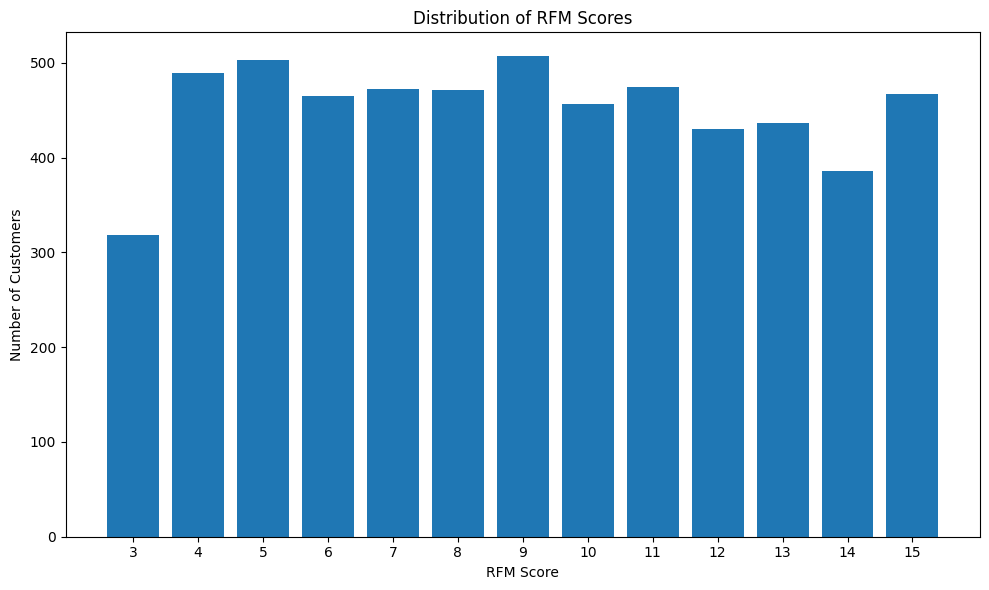

In [55]:
plt.figure(figsize=(10, 6))

plt.bar(
    rfm_score_counts.index.astype(str),
    rfm_score_counts.values
)

plt.title("Distribution of RFM Scores")
plt.xlabel("RFM Score")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

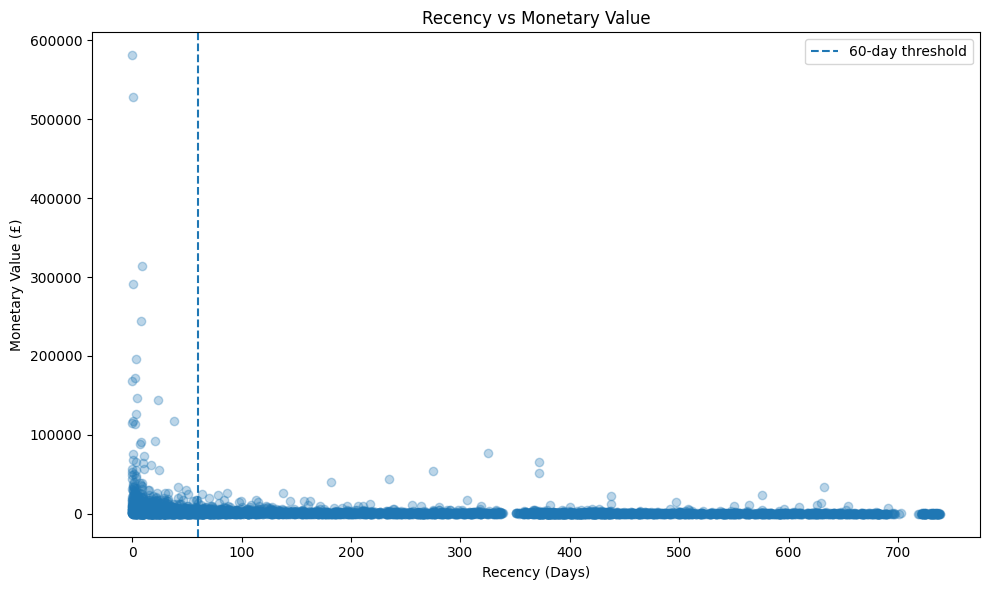

In [56]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm["Recency"],
    rfm["Monetary"],
    alpha=0.3
)

plt.axvline(
    60,
    linestyle="--",
    label="60-day threshold"
)

plt.title("Recency vs Monetary Value")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value (£)")

plt.legend()
plt.tight_layout()
plt.show()

In [57]:
rfm[
    ["Recency", "Frequency", "Monetary"]
].corr()

,Recency,Frequency,Monetary
Recency,1.00,-0.26,-0.13
Frequency,-0.26,1.00,0.63
Monetary,-0.13,0.63,1.00


In [58]:
priority = rfm.copy()

priority["Priority"] = "Standard"

priority.loc[
    (priority["AtRisk60"] == True) &
    (priority["HighValue"] == True),
    "Priority"
] = "High Priority"

priority.loc[
    (priority["AtRisk60"] == True) &
    (priority["HighValue"] == False),
    "Priority"
] = "Retention Opportunity"

In [59]:
priority_summary = (
    priority
    .groupby("Priority")
    .agg(
        Customers=("Customer ID", "nunique"),
        HistoricalValue=("Monetary", "sum"),
        AverageValue=("Monetary", "mean")
    )
    .reset_index()
)

priority_summary

,Priority,Customers,HistoricalValue,AverageValue
0,High Priority,426,"2,448,115.60","5,746.75"
1,Retention Opportunity,3056,"1,948,337.74",637.55
2,Standard,2396,"12,978,350.93","5,416.67"


In [60]:
priority.to_csv(
    "../data/processed/rfm_analysis_dataset.csv",
    index=False
)

print(
    "Saved:",
    "../data/processed/rfm_analysis_dataset.csv"
)

Saved: ../data/processed/rfm_analysis_dataset.csv
